# 유튜버 이탈 확률 예측 모델

## 목표
각 채널에 대해 **"이 유튜버가 이탈할 확률"을 0~1 사이 값으로 출력**합니다.

## 이탈 정의
> 마지막 업로드로부터 **180일(6개월) 이상 경과** → 이탈(1)

## 핵심 원칙 — 데이터 리크 방지
`days_since_last_upload`는 이탈 라벨을 직접 만드는 컬럼이므로 **학습 피처에서 반드시 제외**합니다.  
모델은 업로드 패턴·성과·채널 규모 등 **간접 신호만으로** 이탈을 예측합니다.

## 데이터 활용 전략
| 테이블 | 역할 |
|---|---|
| `dataset_wide` | 채널 단위 집계 피처 (구독자 수, 평균 조회수 등) |
| `dataset_long` | 영상 단위 시계열 → 추가 파생 피처 생성 (최근 추세, 업로드 slope 등) |


## 0. 라이브러리 & 설치

In [2]:
import subprocess, sys


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy.stats                 import linregress
from sklearn.impute              import SimpleImputer
from sklearn.preprocessing       import StandardScaler
from sklearn.pipeline            import Pipeline
from sklearn.model_selection     import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration         import CalibratedClassifierCV, calibration_curve
from sklearn.metrics             import (roc_auc_score, brier_score_loss,
                                         roc_curve, classification_report,
                                         confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

RANDOM_STATE = 42
CHURN_DAYS   = 180   # 이탈 기준 (일)
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("라이브러리 로드 완료")


라이브러리 로드 완료


In [11]:
# 폰트 설정
import matplotlib.pyplot as plt

# macOS에서 가장 많이 사용하는 설정
plt.rcParams["font.family"] = "AppleGothic" # 혹은 "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

print("macOS 한글 폰트 설정 완료")

macOS 한글 폰트 설정 완료


## 1. 데이터 로드

In [5]:
wide = pd.read_csv("data/raw/dataset_wide.csv")
long = pd.read_csv("data/raw/dataset_long.csv")

long["published_at"] = pd.to_datetime(long["published_at"], utc=True, errors="coerce")
long["is_shorts"]    = long["is_shorts"].astype(str).str.lower() == "true"

NOW = pd.Timestamp.now(tz="UTC")

print(f"wide : {wide.shape}")
print(f"long : {long.shape}")


wide : (8083, 22)
long : (376988, 18)


## 2. 이탈 라벨 생성

`days_since_last_upload >= 180` → `is_churned = 1`


=== 라벨 분포 ===
is_churned
0    5379
1    2704
Name: count, dtype: int64

이탈률: 33.5%


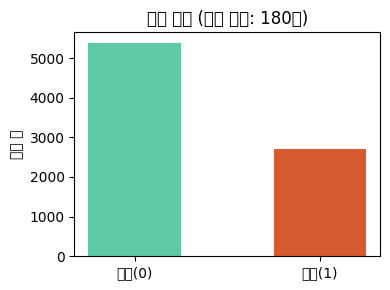

In [6]:
wide["is_churned"] = (wide["days_since_last_upload"] >= CHURN_DAYS).astype(int)

print("=== 라벨 분포 ===")
vc = wide["is_churned"].value_counts()
print(vc)
print(f"\n이탈률: {wide['is_churned'].mean():.1%}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["활성(0)","이탈(1)"], vc.values,
       color=["#5DCAA5","#D85A30"], edgecolor="none", width=0.5)
ax.set_ylabel("채널 수")
ax.set_title(f"라벨 분포 (이탈 기준: {CHURN_DAYS}일)")
plt.tight_layout(); plt.show()


## 3. wide 피처 전처리

`days_since_last_upload`는 라벨 생성에 사용한 컬럼이므로 **제외**합니다.


In [7]:
# channel_age_days 생성
wide["published_at"]     = pd.to_datetime(wide["published_at"], format="mixed", utc=True, errors="coerce")
wide["channel_age_days"] = (NOW - wide["published_at"]).dt.days
wide["channel_age_days"] = wide["channel_age_days"].fillna(wide["channel_age_days"].median())

# 이상값 처리
wide["upload_freq_change_rate"] = wide["upload_freq_change_rate"].clip(-5, 5)
wide["avg_engagement_rate"]     = wide["avg_engagement_rate"].clip(0, 1)
wide["avg_shorts_view"]         = wide["avg_shorts_view"].fillna(0)
wide["avg_normal_view"]         = wide["avg_normal_view"].fillna(0)

WIDE_FEATURES = [
    # 채널 규모
    "channel_age_days", "subscriber_count", "view_count", "total_video_count",
    # 활동성 (days_since_last_upload 제외)
    "collected_video_count",
    "avg_upload_interval_days", "std_upload_interval_days",
    "max_gap_days", "hiatus_count_30d", "upload_freq_change_rate",
    # 성과
    "avg_view_count", "std_view_count",
    "avg_like_count", "avg_comment_count", "avg_engagement_rate",
    # Shorts
    "shorts_ratio", "avg_shorts_view", "avg_normal_view",
]

print(f"wide 피처 수: {len(WIDE_FEATURES)}")
print()
null_check = wide[WIDE_FEATURES].isnull().sum()
print("null 현황:")
print(null_check[null_check > 0] if null_check.any() else "  없음 ✓")


wide 피처 수: 18

null 현황:
avg_upload_interval_days     53
std_upload_interval_days     53
max_gap_days                 51
std_view_count               51
avg_like_count              174
avg_comment_count            84
avg_engagement_rate         246
dtype: int64


## 4. dataset_long → 추가 시계열 피처

wide에 없는 **최근 추세** 관련 피처를 long 테이블에서 추출합니다.

| 피처 | 설명 |
|---|---|
| `upload_slope` | 월별 업로드 수의 선형 기울기 — 음수면 업로드 감소 추세 |
| `recent_3m_upload_count` | 최근 3개월 업로드 수 |
| `recent_view_ratio` | 최근 10개 영상 평균 조회수 / 전체 평균 — 1 미만이면 최근 성과 하락 |
| `days_between_last2` | 마지막 두 영상 사이 간격 — 직전 공백이 길수록 이탈 신호 |


In [8]:
def extract_long_features(group):
    g = group.sort_values("published_at")

    # ── upload_slope: 월별 업로드 수 선형 기울기 ──────────────────────────
    g["ym"] = g["published_at"].dt.to_period("M")
    monthly = g.groupby("ym").size().reset_index(name="cnt")
    if len(monthly) >= 3:
        slope, *_ = linregress(range(len(monthly)), monthly["cnt"])
    else:
        slope = np.nan

    # ── recent_3m_upload_count ────────────────────────────────────────────
    t3 = NOW - pd.Timedelta(days=90)
    recent_3m = (g["published_at"] >= t3).sum()

    # ── recent_view_ratio ─────────────────────────────────────────────────
    views = g["view_count"].dropna().tolist()
    if len(views) >= 10:
        recent_avg = np.mean(views[-10:])   # 최신 10개 (오름차순이므로 뒤가 최신)
        total_avg  = np.mean(views)
        view_ratio = round(recent_avg / (total_avg + 1e-9), 4)
    else:
        view_ratio = np.nan

    # ── days_between_last2: 마지막 두 영상 사이 간격 ─────────────────────
    dates = g["published_at"].dropna().tolist()
    if len(dates) >= 2:
        days_last2 = (dates[-1] - dates[-2]).days
    else:
        days_last2 = np.nan

    return pd.Series({
        "upload_slope"            : round(slope, 4) if not np.isnan(slope) else np.nan,
        "recent_3m_upload_count"  : int(recent_3m),
        "recent_view_ratio"       : view_ratio,
        "days_between_last2"      : days_last2,
    })

long_feat = long.groupby("channel_id").apply(
    extract_long_features, include_groups=False
).reset_index()

print(f"long 추가 피처 shape: {long_feat.shape}")
print()
print(long_feat.describe().round(3))


long 추가 피처 shape: (8092, 5)

       upload_slope  recent_3m_upload_count  recent_view_ratio  \
count      6796.000                 8092.00           7812.000   
mean         -0.401                   17.86              0.785   
std           2.495                   20.52              0.614   
min         -23.000                    0.00              0.000   
25%          -0.643                    0.00              0.377   
50%          -0.100                    7.00              0.664   
75%           0.094                   41.00              1.003   
max          22.500                   50.00              4.923   

       days_between_last2  
count            8032.000  
mean               52.788  
std               195.287  
min                 0.000  
25%                 0.000  
50%                 3.000  
75%                14.000  
max              3616.000  


## 5. wide + long 피처 병합

In [9]:
df = wide[["channel_id","title","is_churned"] + WIDE_FEATURES].merge(
    long_feat, on="channel_id", how="left"
)

LONG_FEATURES = ["upload_slope","recent_3m_upload_count","recent_view_ratio","days_between_last2"]
ALL_FEATURES  = WIDE_FEATURES + LONG_FEATURES

X = df[ALL_FEATURES].copy()
y = df["is_churned"].copy()

print(f"최종 피처 수 : {len(ALL_FEATURES)}")
print(f"샘플 수      : {len(X)}")
print(f"이탈률       : {y.mean():.1%}")
print()
null_check = X.isnull().sum()
print("null 현황:")
print(null_check[null_check > 0] if null_check.any() else "  없음 ✓")


최종 피처 수 : 22
샘플 수      : 8083
이탈률       : 33.5%

null 현황:
avg_upload_interval_days      53
std_upload_interval_days      53
max_gap_days                  51
std_view_count                51
avg_like_count               174
avg_comment_count             84
avg_engagement_rate          246
upload_slope                1287
recent_view_ratio            271
days_between_last2            51
dtype: int64


## 6. 피처-라벨 상관관계 확인

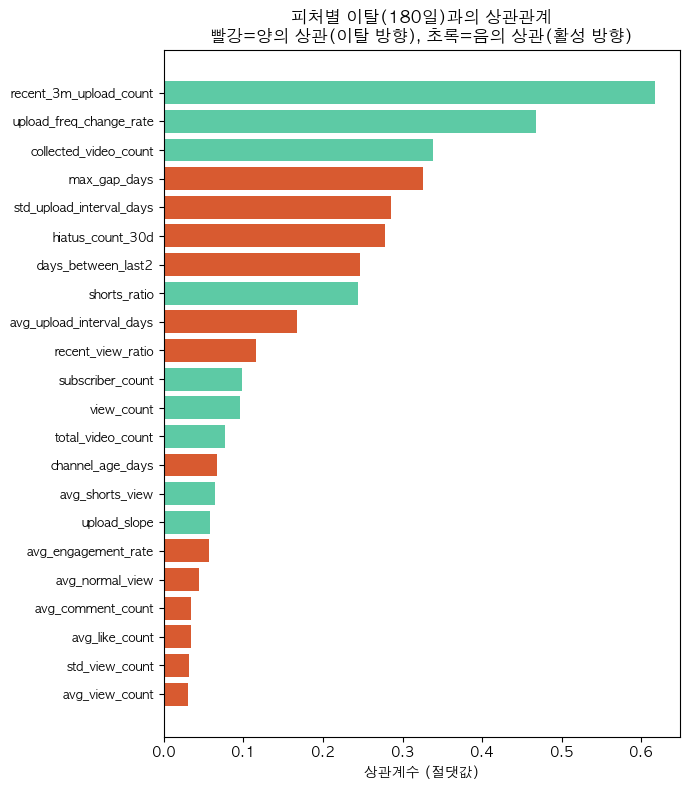

In [12]:
corr = df[ALL_FEATURES + ["is_churned"]].corr()["is_churned"].drop("is_churned")
corr_sorted = corr.abs().sort_values(ascending=True)

colors = ["#D85A30" if corr[f] > 0 else "#5DCAA5" for f in corr_sorted.index]

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor="none")
ax.set_xlabel("상관계수 (절댓값)")
ax.set_title("피처별 이탈(180일)과의 상관관계\n빨강=양의 상관(이탈 방향), 초록=음의 상관(활성 방향)")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.show()


## 7. 모델 정의

**확률 출력을 위한 핵심 설정: `predict_proba`**

모든 모델은 `predict_proba(X)[:, 1]`로 **이탈 확률(0~1)**을 출력합니다.  
확률 보정(Calibration)이 필요한 모델(LR 제외)은 `CalibratedClassifierCV`로 감쌉니다.

> **Brier Score**: 확률 예측의 정확도 지표. 낮을수록 좋음 (0 = 완벽, 0.25 = 랜덤)


In [13]:
pos_weight = (y == 0).sum() / (y == 1).sum()

# XGBoost base (보정 전)
xgb_base = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 3,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    verbosity        = 0,
)

models = {
    "Logistic Regression": Pipeline([
        ("imp",  SimpleImputer(strategy="median")),
        ("sc",   StandardScaler()),
        ("clf",  LogisticRegression(
            class_weight="balanced", C=0.1,
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=5,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost (calibrated)": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", CalibratedClassifierCV(xgb_base, cv=3, method="isotonic")),
    ]),
}

print("모델 정의 완료")
for name, m in models.items():
    print(f"  - {name}")


모델 정의 완료
  - Logistic Regression
  - Random Forest
  - XGBoost (calibrated)


## 8. 교차검증 — AUC & Brier Score

In [14]:
results = {}

for name, model in models.items():
    # AUC
    cv_res = cross_validate(model, X, y, cv=CV,
                            scoring=["roc_auc","f1","recall","precision"])
    # Brier Score (확률 보정 품질)
    y_prob_cv = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    brier     = brier_score_loss(y, y_prob_cv)

    results[name] = {
        "AUC-ROC" : cv_res["test_roc_auc"].mean(),
        "F1"      : cv_res["test_f1"].mean(),
        "Recall"  : cv_res["test_recall"].mean(),
        "Precision": cv_res["test_precision"].mean(),
        "Brier↓"  : brier,   # 낮을수록 좋음
    }
    print(f"[{name}] AUC={results[name]['AUC-ROC']:.3f}  Brier={brier:.3f}")

res_df = pd.DataFrame(results).T.round(3)
print()
res_df


[Logistic Regression] AUC=0.960  Brier=0.080
[Random Forest] AUC=1.000  Brier=0.021
[XGBoost (calibrated)] AUC=1.000  Brier=0.000



,AUC-ROC,F1,Recall,Precision,Brier↓
Logistic Regression,0.96,0.861,0.996,0.759,0.080
Random Forest,1.00,0.981,1.000,0.963,0.021
XGBoost (calibrated),1.00,1.000,1.000,1.000,0.000


## 9. 확률 보정(Calibration) 시각화

**Calibration Curve**: 모델이 예측한 확률이 실제 이탈 비율과 얼마나 일치하는지 보여줍니다.  
대각선(완벽한 보정)에 가까울수록 신뢰할 수 있는 확률입니다.


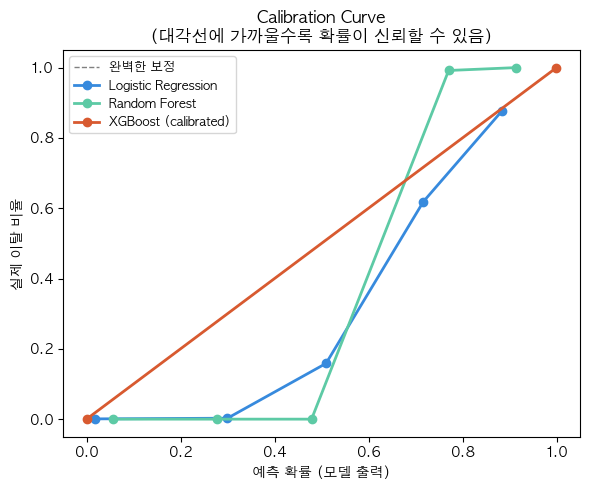

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0,1],[0,1],"--", color="gray", lw=1, label="완벽한 보정")

colors_cal = {"Logistic Regression":"#378ADD",
              "Random Forest":"#5DCAA5",
              "XGBoost (calibrated)":"#D85A30"}

for name, model in models.items():
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    fraction_pos, mean_pred = calibration_curve(y, y_prob, n_bins=5, strategy="uniform")
    ax.plot(mean_pred, fraction_pos, "o-", label=name, color=colors_cal[name], lw=2)

ax.set_xlabel("예측 확률 (모델 출력)")
ax.set_ylabel("실제 이탈 비율")
ax.set_title("Calibration Curve\n(대각선에 가까울수록 확률이 신뢰할 수 있음)")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 10. ROC 커브 비교

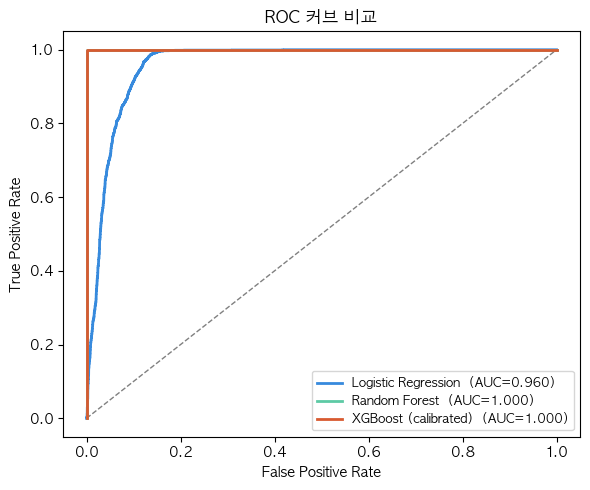

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0,1],[0,1],"--", color="gray", lw=1)

for name, model in models.items():
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    ax.plot(fpr, tpr, lw=2, label=f"{name}  (AUC={auc:.3f})",
            color=colors_cal[name])

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC 커브 비교")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 11. 채널별 이탈 확률 출력

전체 데이터로 재학습한 모델로 각 채널의 이탈 확률을 계산합니다.  
**3개 모델의 평균 확률**을 최종 `churn_prob`로 사용합니다 (앙상블).


In [17]:
from sklearn.impute import SimpleImputer

# 전체 데이터로 재학습
prob_dict = {}
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=ALL_FEATURES)

for name, model in models.items():
    model.fit(X_imputed, y)
    prob_dict[name] = model.predict_proba(X_imputed)[:, 1]

# 앙상블: 3개 모델 평균
probs_df = pd.DataFrame(prob_dict)
probs_df["churn_prob"] = probs_df.mean(axis=1)   # 앙상블 평균
probs_df["channel_id"] = df["channel_id"].values
probs_df["title"]      = df["title"].values
probs_df["is_churned"] = y.values

# 이탈 확률 기준 정렬
output = probs_df[["channel_id","title","is_churned",
                   "Logistic Regression","Random Forest",
                   "XGBoost (calibrated)","churn_prob"]].sort_values(
    "churn_prob", ascending=False
).reset_index(drop=True)

output.columns = ["channel_id","title","actual_label",
                  "prob_lr","prob_rf","prob_xgb","churn_prob"]
output = output.round(3)
print(f"이탈 확률 계산 완료: {len(output)}개 채널")
output


이탈 확률 계산 완료: 8083개 채널


,channel_id,title,actual_label,prob_lr,prob_rf,prob_xgb,churn_prob
0,UC65vZS-OBv7fTI76e-QzayQ,버벅쓰BUBUX,1,0.990,0.971,1.0,0.987
1,UCiqOl-biosMUfZwEua8bRzw,비방송yong,1,0.991,0.970,1.0,0.987
2,UCQ0JZGdoxgBH1CYL1V3llnw,LearnVibe,1,0.988,0.971,1.0,0.987
3,UCcMvwWMSjHoFtf9nxYet9nw,갓파,1,0.994,0.965,1.0,0.986
4,UC4vD5JpdxZRPy1bpRAdjhSA,조랭몬 YouTube,1,0.990,0.968,1.0,0.986
...,...,...,...,...,...,...,...
8078,UC6oRqb8L9Cv8yOu8hm4E__g,Koreanet,0,0.000,0.007,0.0,0.002
8079,UCpmctTnUfbeoycGhieZQAmw,DanalEntertainment,0,0.000,0.007,0.0,0.002
8080,UCKNZsAeQXpvI-Mpoc0ZKhsA,Mhz 므흐즈: MBC RADIO,0,0.000,0.007,0.0,0.002
8081,UCFhvPGzMa67wJTx_wiVIcSQ,춤추는곰돌,0,0.000,0.007,0.0,0.002


## 12. 채널별 이탈 확률 시각화

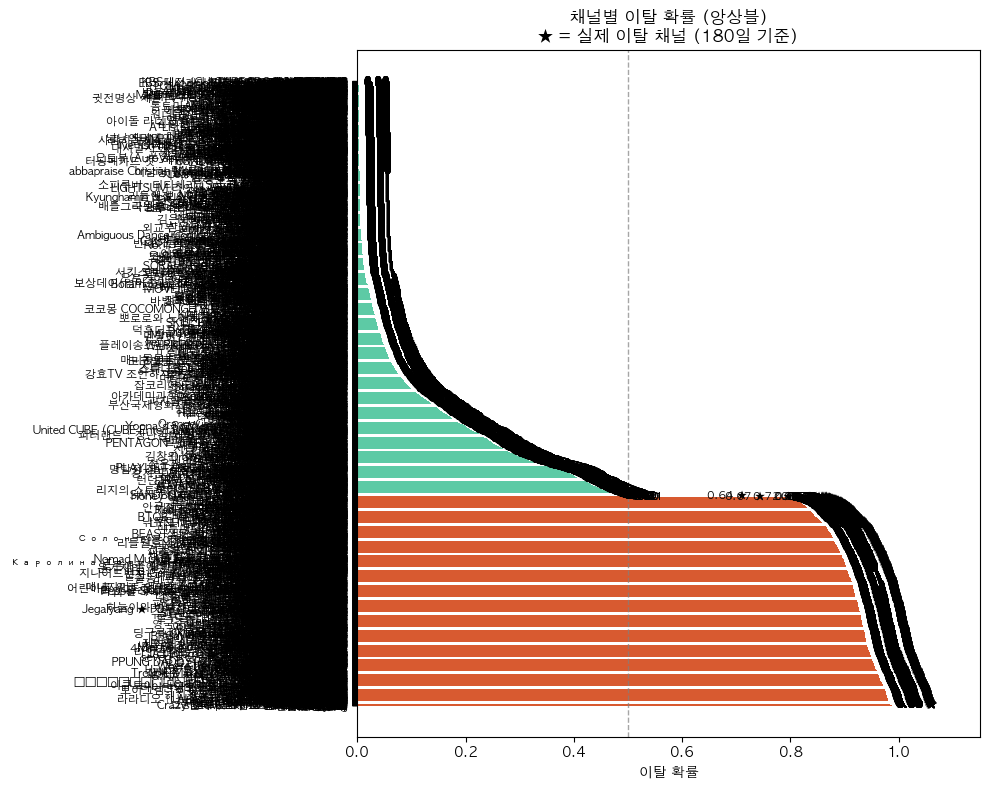

In [18]:
fig, ax = plt.subplots(figsize=(10, 8))

colors_bar = ["#D85A30" if v >= 0.5 else "#5DCAA5" for v in output["churn_prob"]]
bars = ax.barh(output["title"], output["churn_prob"],
               color=colors_bar, edgecolor="none")

# 실제 이탈 채널 표시
for i, (prob, actual) in enumerate(zip(output["churn_prob"], output["actual_label"])):
    marker = " ★" if actual == 1 else ""
    ax.text(prob + 0.01, i, f"{prob:.2f}{marker}", va="center", fontsize=8)

ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("이탈 확률")
ax.set_title("채널별 이탈 확률 (앙상블)\n★ = 실제 이탈 채널 (180일 기준)")
ax.set_xlim(0, 1.15)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()


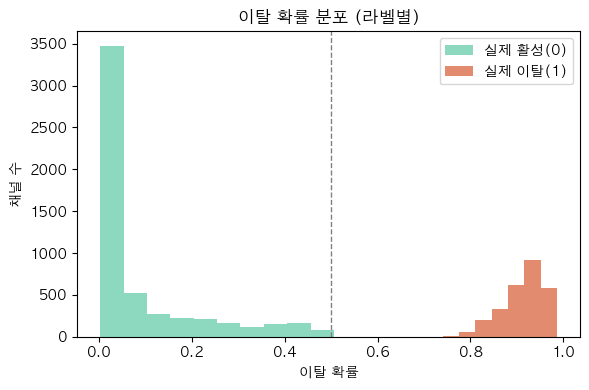

In [19]:
# 이탈 확률 분포
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(output[output["actual_label"]==0]["churn_prob"],
        bins=10, alpha=0.7, color="#5DCAA5", label="실제 활성(0)", edgecolor="none")
ax.hist(output[output["actual_label"]==1]["churn_prob"],
        bins=10, alpha=0.7, color="#D85A30", label="실제 이탈(1)", edgecolor="none")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("이탈 확률")
ax.set_ylabel("채널 수")
ax.set_title("이탈 확률 분포 (라벨별)")
ax.legend()
plt.tight_layout(); plt.show()


## 13. 결과 저장

In [20]:
output.to_csv("churn_probability_output.csv", index=False, encoding="utf-8-sig")
print("저장 완료: churn_probability_output.csv")
print()
print("=== 이탈 확률 상위 10개 채널 ===")
print(output[["title","churn_prob","actual_label"]].head(10).to_string(index=False))


저장 완료: churn_probability_output.csv

=== 이탈 확률 상위 10개 채널 ===
        title  churn_prob  actual_label
     버벅쓰BUBUX       0.987             1
      비방송yong       0.987             1
    LearnVibe       0.987             1
           갓파       0.986             1
  조랭몬 YouTube       0.986             1
      키티하츄핑공주       0.986             1
          김스타       0.985             1
         빵집TV       0.985             1
JasonIsKorean       0.985             1
           얌미       0.985             1


## 14. 결과 해석 가이드

### 이탈 확률 구간별 의미

| 확률 구간 | 해석 | 권장 행동 |
|---|---|---|
| 0.0 ~ 0.3 | 이탈 가능성 낮음 | 모니터링 유지 |
| 0.3 ~ 0.5 | 다소 불안정 | 주기적 관찰 필요 |
| 0.5 ~ 0.7 | 이탈 위험 | 선제적 대응 고려 |
| 0.7 ~ 1.0 | 이탈 고위험 | 즉각적 개입 필요 |

### Brier Score 해석
- `0.00` : 완벽한 확률 예측
- `0.25` : 랜덤 예측 수준
- 낮을수록 확률 자체의 신뢰도가 높음

### 현재 한계 및 다음 단계
> 현재 **50개 샘플**에서 나온 확률은 방향성 참고용입니다.  
> 전체 데이터(~8191채널) 통합 후 재실행하면 신뢰할 수 있는 확률을 얻을 수 있습니다.
